In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT_DIR = Path.cwd().parent
HISTORY_PATH = ROOT_DIR / "reports" / "tables" / "cnn_histories.json"

with open(HISTORY_PATH, "r") as f:
    cnn_histories = json.load(f)

print(f"Loaded {len(cnn_histories)} experiment histories")

Loaded 16 experiment histories


In [3]:
records = []

for experiment in cnn_histories:
    config = experiment["config"]
    history = experiment["history"]
    exp_index = experiment["index"]

    epochs = range(1, len(history["accuracy"]) + 1)

    for epoch_idx, epoch in enumerate(epochs):
        records.append({
            "experiment": exp_index,
            "epoch": epoch,
            "accuracy": history["accuracy"][epoch_idx],
            "val_accuracy": history["val_accuracy"][epoch_idx],
            "loss": history["loss"][epoch_idx],
            "val_loss": history["val_loss"][epoch_idx],
            "filters": config["filters"],
            "kernel_size": config["kernel_size"],
            "num_layers": config["num_layers"],
            "pooling_type": config["pooling_type"],
        })

df = pd.DataFrame(records)

display(df.head())

,experiment,epoch,accuracy,val_accuracy,loss,val_loss,filters,kernel_size,num_layers,pooling_type
0,1,1,0.639352,0.722480,0.999433,0.780500,32,3,2,max
1,1,2,0.807963,0.711436,0.548772,0.840410,32,3,2,max
2,1,3,0.919034,0.738155,0.263982,0.931292,32,3,2,max
3,1,4,0.972922,0.752761,0.110907,1.003855,32,3,2,max
4,1,5,0.987530,0.742786,0.064407,1.153044,32,3,2,max


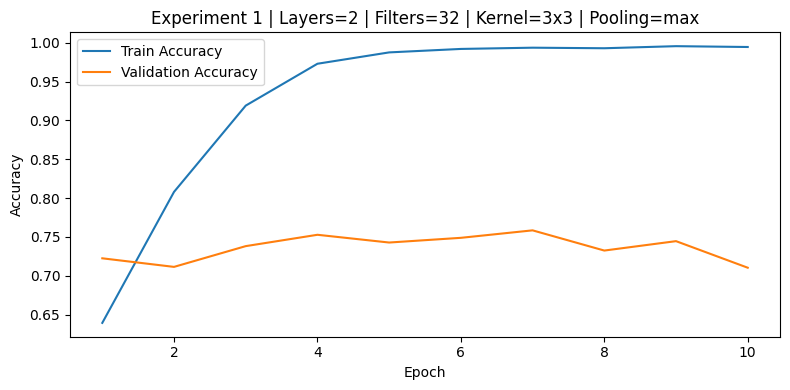

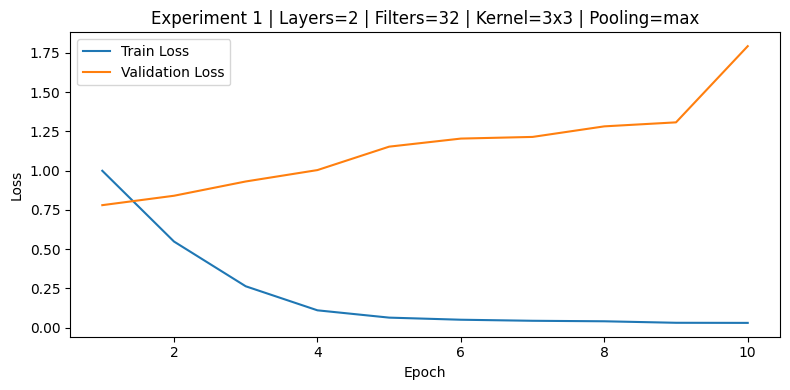

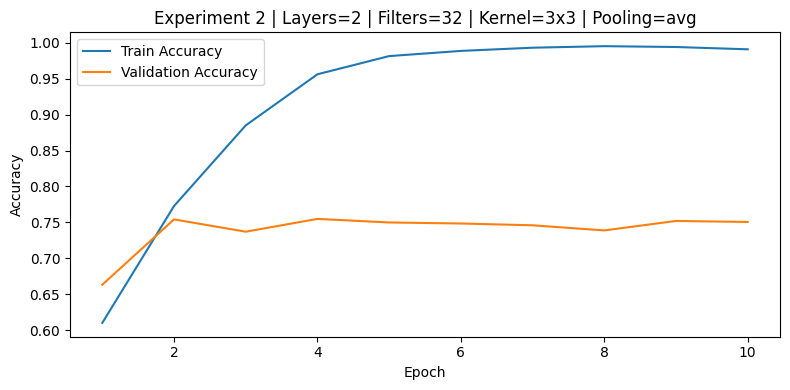

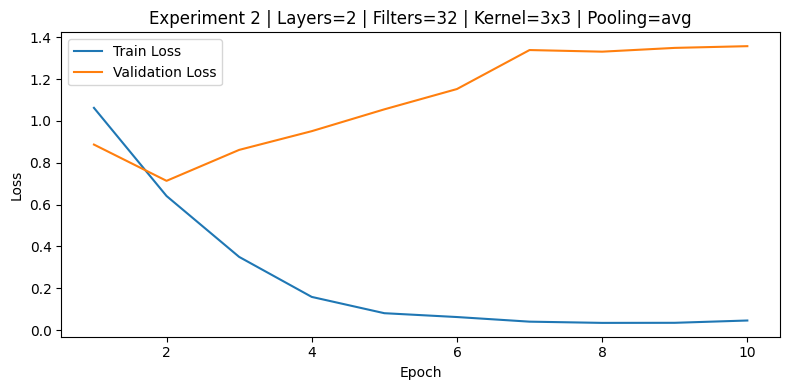

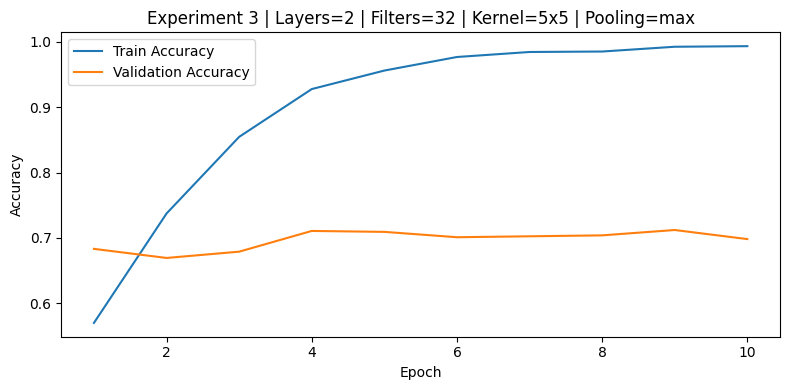

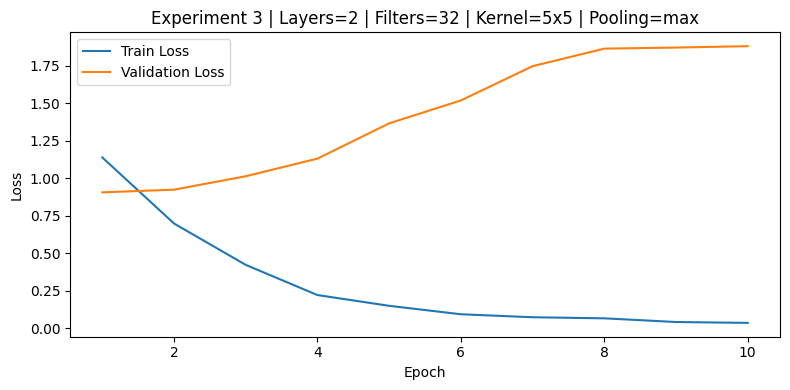

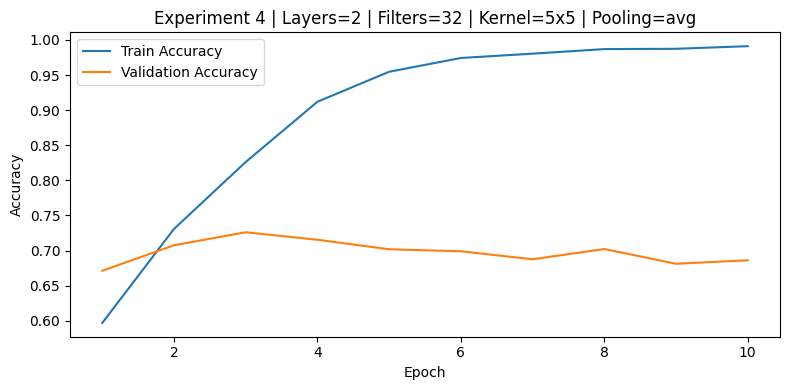

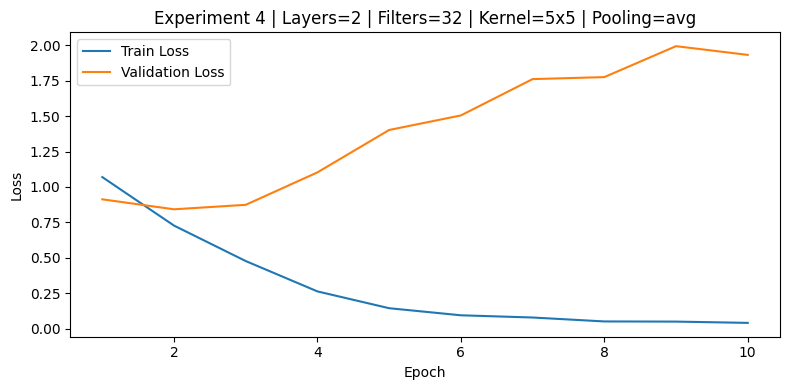

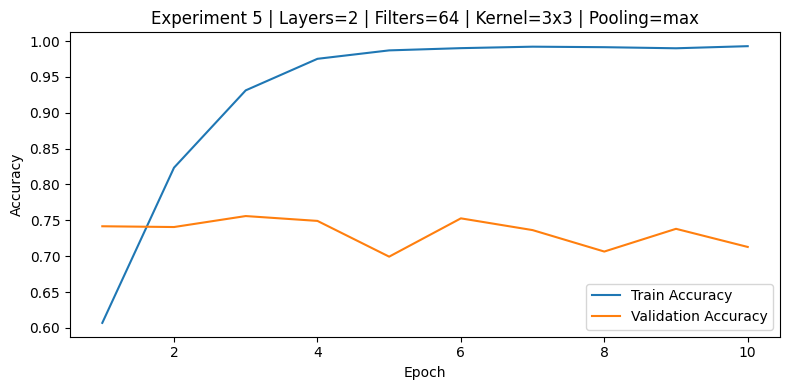

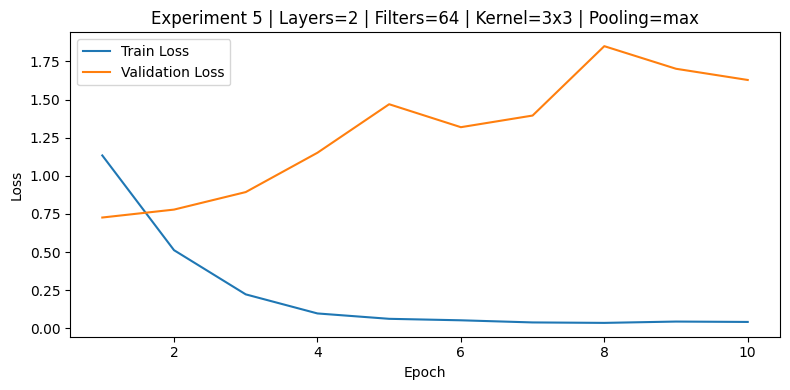

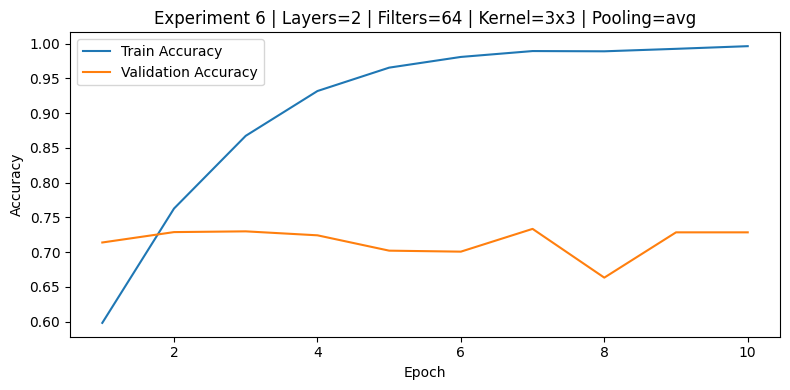

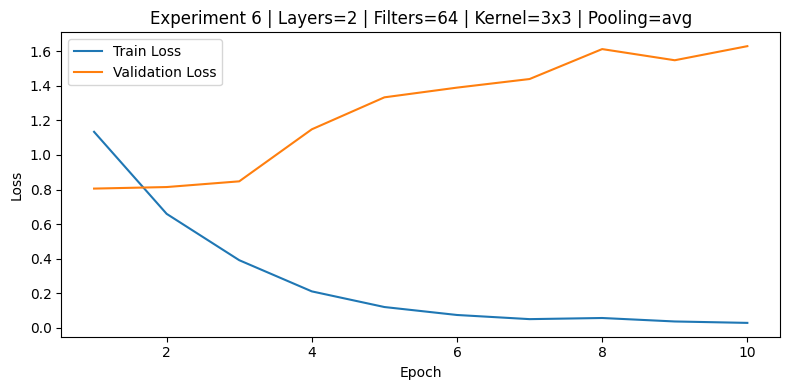

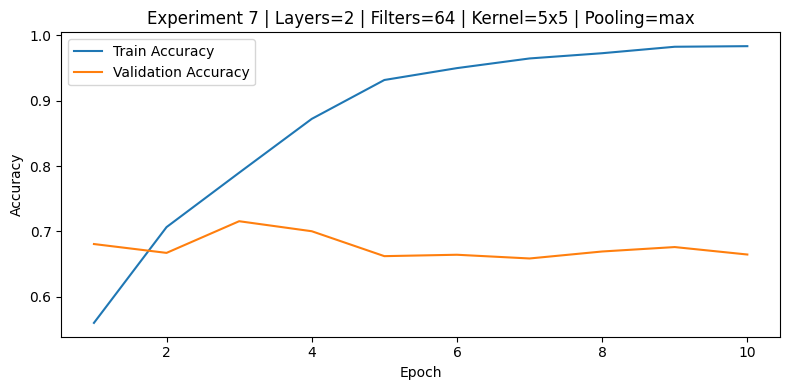

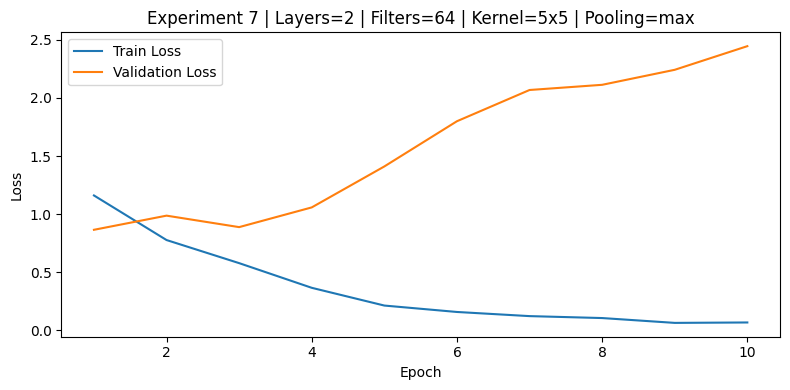

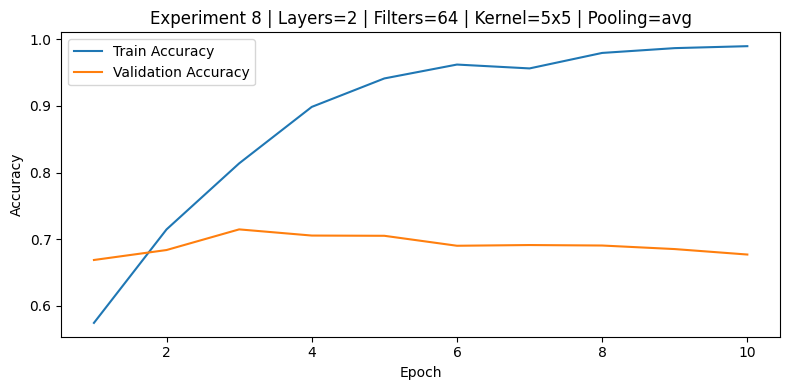

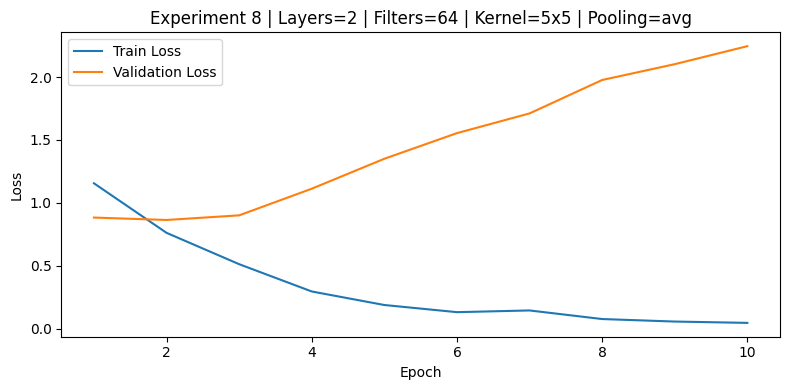

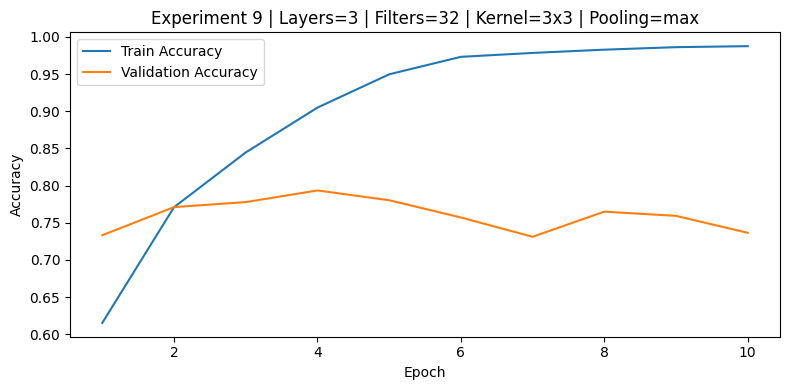

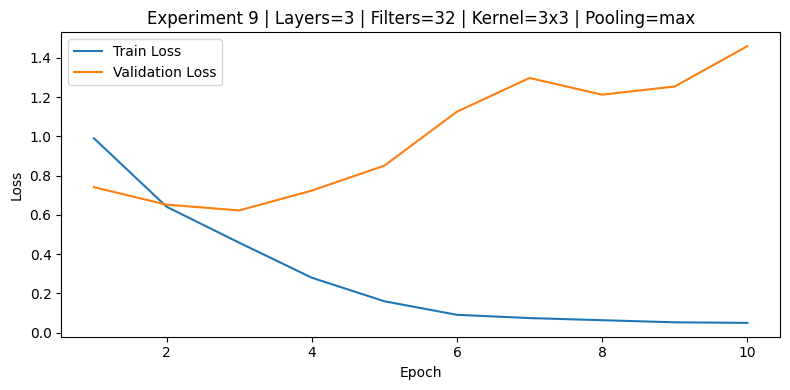

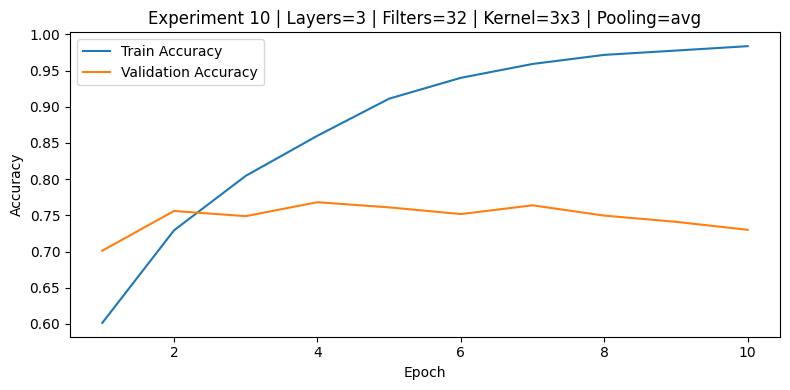

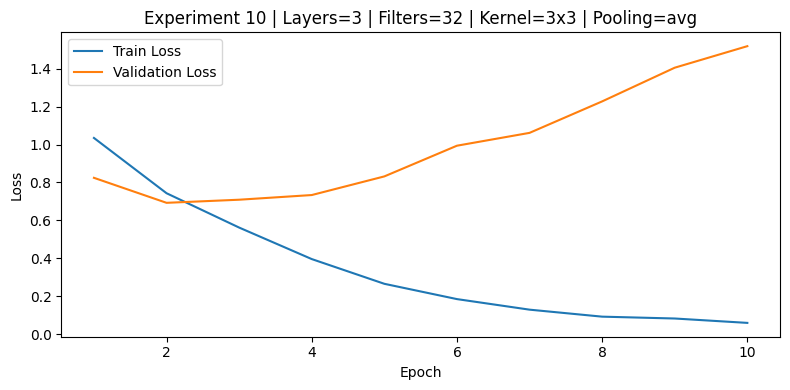

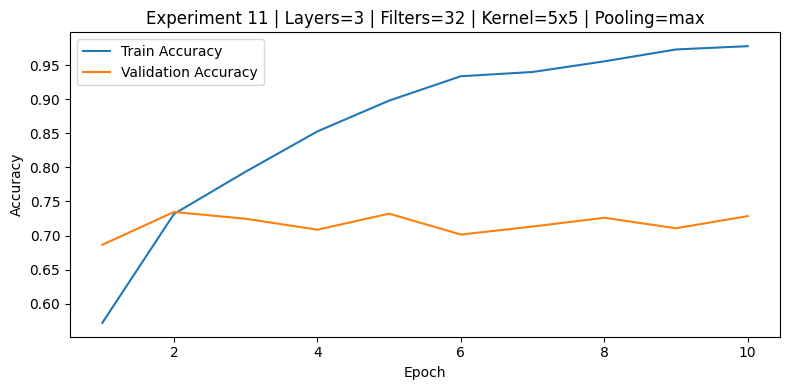

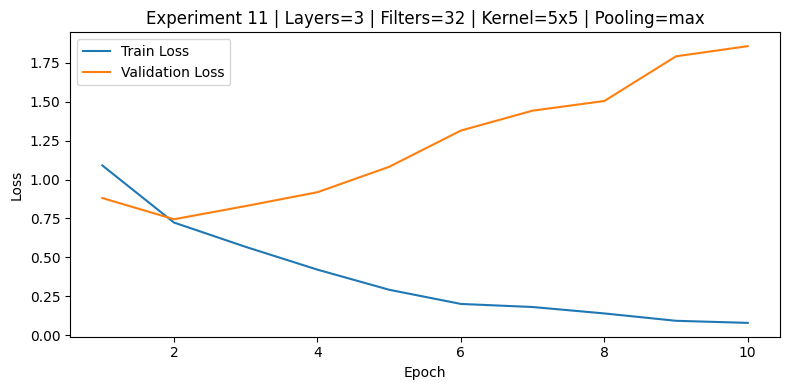

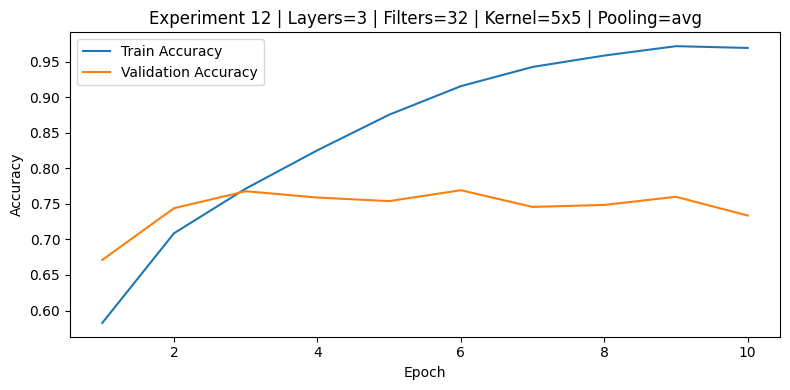

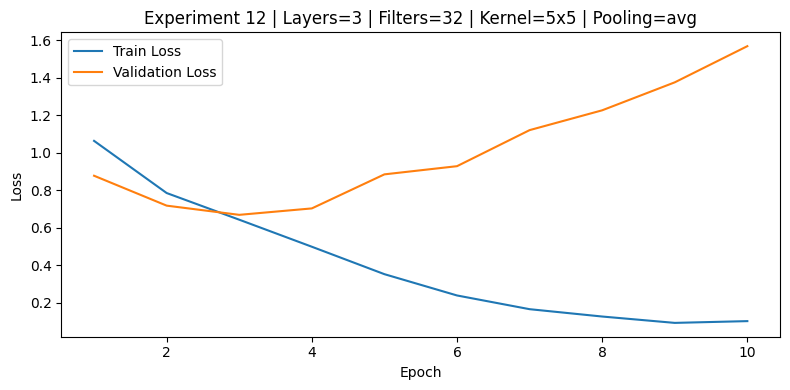

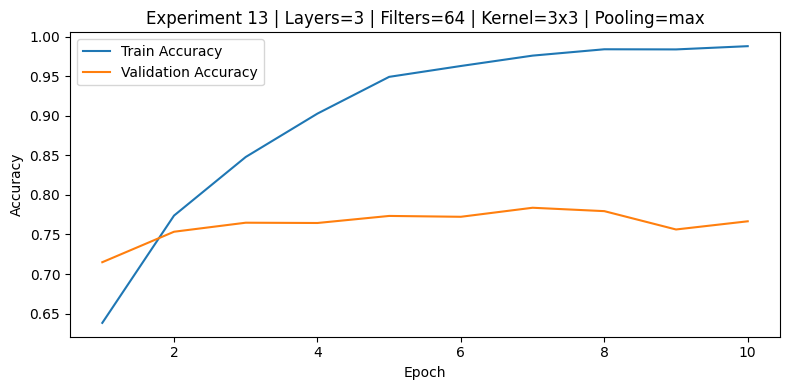

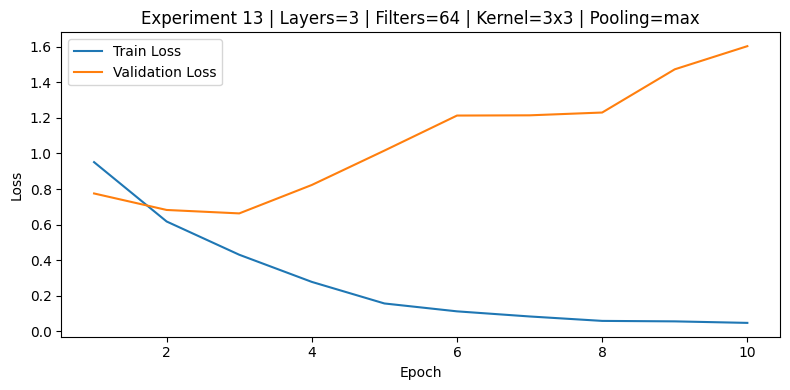

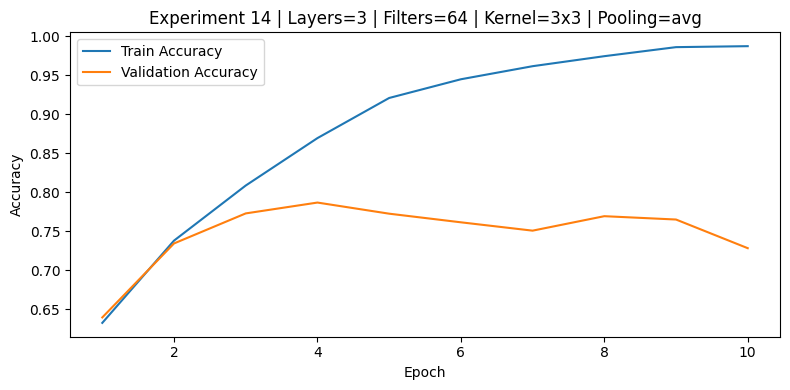

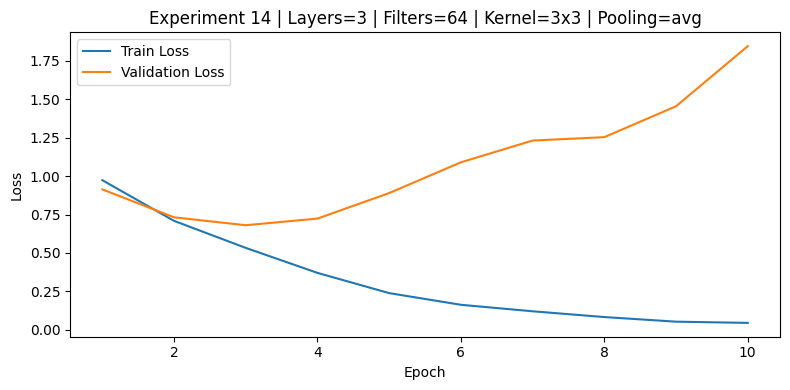

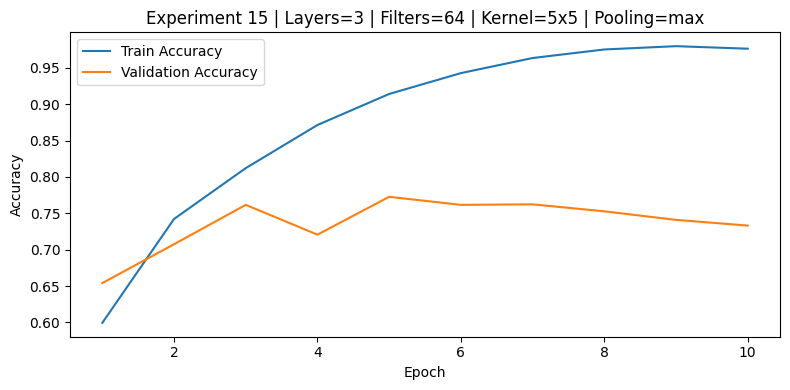

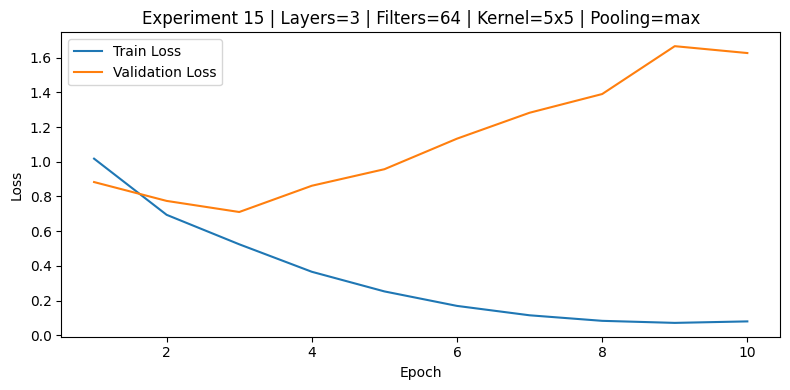

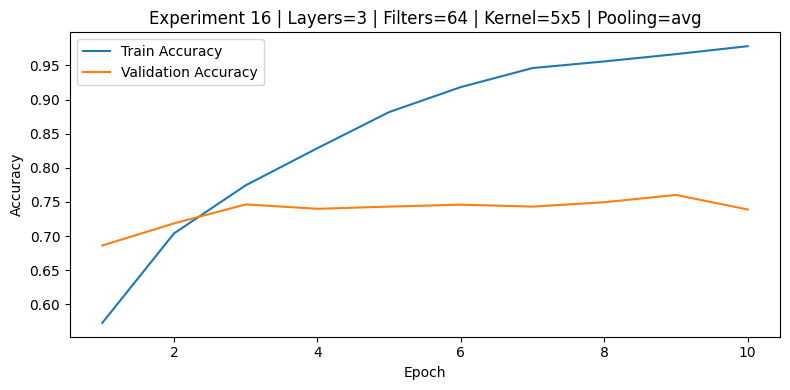

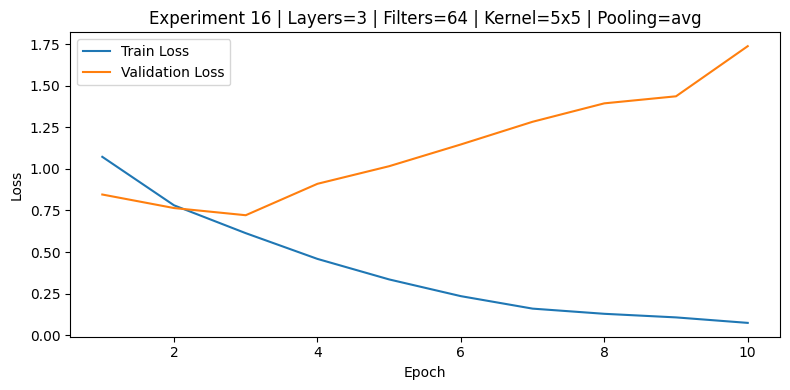


[SUCCESS] Visualizations saved to:
c:\Users\HP\Documents\Semester 6\ML\Tubes 2\ML-Tubes-2_RecursiveLearnaholic\reports\figures\cnn_histories


In [5]:
SAVE_DIR = ROOT_DIR / "reports" / "figures" / "cnn_histories"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for exp_id in sorted(df["experiment"].unique()):

    exp_df = df[df["experiment"] == exp_id]

    config = {
        "filters": exp_df["filters"].iloc[0],
        "kernel_size": exp_df["kernel_size"].iloc[0],
        "num_layers": exp_df["num_layers"].iloc[0],
        "pooling_type": exp_df["pooling_type"].iloc[0],
    }

    title = (
        f"Experiment {exp_id} | "
        f"Layers={config['num_layers']} | "
        f"Filters={config['filters']} | "
        f"Kernel={config['kernel_size']}x{config['kernel_size']} | "
        f"Pooling={config['pooling_type']}"
    )

    plt.figure(figsize=(8, 4))

    plt.plot(
        exp_df["epoch"],
        exp_df["accuracy"],
        label="Train Accuracy"
    )

    plt.plot(
        exp_df["epoch"],
        exp_df["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        SAVE_DIR / f"experiment_{exp_id:02d}_accuracy.png",
        dpi=160
    )

    plt.show()

    plt.figure(figsize=(8, 4))

    plt.plot(
        exp_df["epoch"],
        exp_df["loss"],
        label="Train Loss"
    )

    plt.plot(
        exp_df["epoch"],
        exp_df["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        SAVE_DIR / f"experiment_{exp_id:02d}_loss.png",
        dpi=160
    )

    plt.show()

print(f"\n[SUCCESS] Visualizations saved to:\n{SAVE_DIR}")

In [11]:
CSV_PATH = ROOT_DIR / "reports" / "tables" / "cnn_records.csv"
cnn_df = pd.read_csv(CSV_PATH)
display(cnn_df.head())

,index,experiment_id,num_layers,filters,kernel_size,pooling_type,macro_f1,model_path,keras_weight_path,history_path,shared_parameters
0,1,0,2,32,3,max,0.707264,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
1,2,1,2,32,3,avg,0.737065,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
2,3,2,2,32,5,max,0.695736,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
3,4,3,2,32,5,avg,0.688956,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
4,5,4,2,64,3,max,0.708734,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True


In [12]:
def get_f1(config_index):
    """
    Retrieve Macro F1 score using 1-indexed configuration number.
    """
    row = cnn_df[cnn_df["index"] == config_index]

    if row.empty:
        raise ValueError(f"Configuration {config_index} not found")

    return float(row["macro_f1"].iloc[0])

def build_pairs(index_pairs):
    """
    Convert config index pairs into plotting structure.

    Example:
    [(1, 9), (2, 10)]
    ->
    [
        ((1, f1_1), (9, f1_9)),
        ...
    ]
    """
    pairs = []

    for left_idx, right_idx in index_pairs:
        left_f1 = get_f1(left_idx)
        right_f1 = get_f1(right_idx)

        pairs.append(
            (
                (left_idx, left_f1),
                (right_idx, right_f1)
            )
        )

    return pairs

def plot_pairwise_comparison(
    pairs,
    title,
    left_label,
    right_label,
    filename
):
    labels = []
    left_values = []
    right_values = []

    for left_pair, right_pair in pairs:

        left_idx, left_f1 = left_pair
        right_idx, right_f1 = right_pair

        labels.append(f"{left_idx} vs {right_idx}")

        left_values.append(left_f1)
        right_values.append(right_f1)

    x = range(len(labels))
    width = 0.35

    plt.figure(figsize=(14, 5))

    plt.bar(
        [i - width / 2 for i in x],
        left_values,
        width=width,
        label=left_label
    )

    plt.bar(
        [i + width / 2 for i in x],
        right_values,
        width=width,
        label=right_label
    )

    plt.xticks(list(x), labels)

    plt.xlabel("Configuration Pair")
    plt.ylabel("Macro F1")
    plt.title(title)

    plt.legend()

    plt.tight_layout()

    SAVE_DIR = ROOT_DIR / "reports" / "figures"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    plt.savefig(SAVE_DIR / filename, dpi=160)

    plt.show()

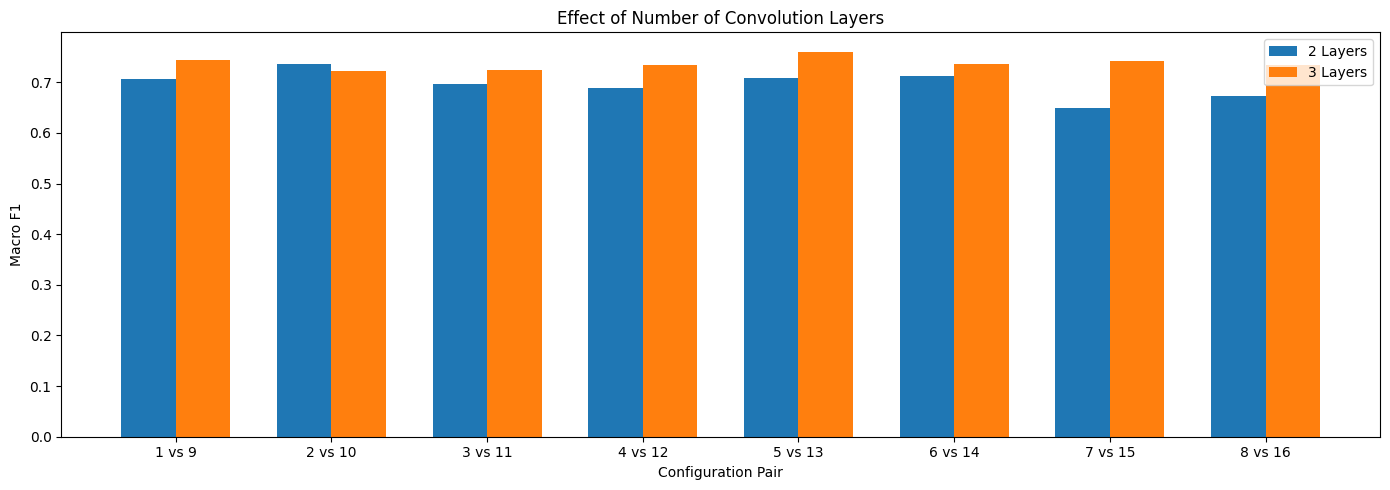

In [13]:
layer_index_pairs = [
    (1, 9),
    (2, 10),
    (3, 11),
    (4, 12),
    (5, 13),
    (6, 14),
    (7, 15),
    (8, 16),
]

layer_pairs = build_pairs(layer_index_pairs)

plot_pairwise_comparison(
    pairs=layer_pairs,
    title="Effect of Number of Convolution Layers",
    left_label="2 Layers",
    right_label="3 Layers",
    filename="cnn_effect_num_layers.png"
)

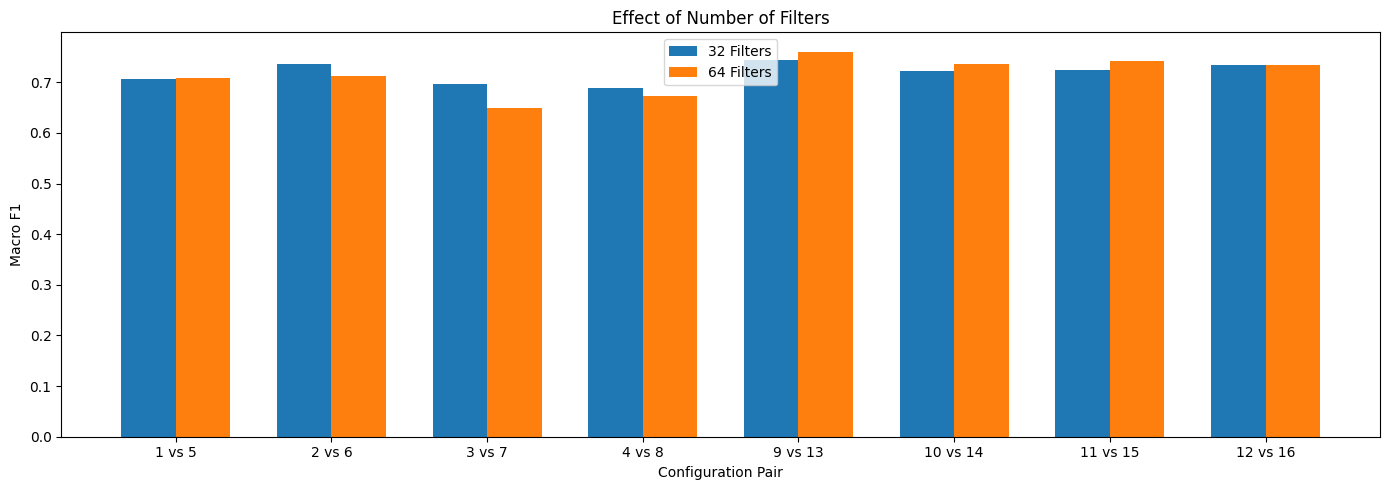

In [14]:
filter_index_pairs = [
    (1, 5),
    (2, 6),
    (3, 7),
    (4, 8),
    (9, 13),
    (10, 14),
    (11, 15),
    (12, 16),
]

filter_pairs = build_pairs(filter_index_pairs)

plot_pairwise_comparison(
    pairs=filter_pairs,
    title="Effect of Number of Filters",
    left_label="32 Filters",
    right_label="64 Filters",
    filename="cnn_effect_filters.png"
)

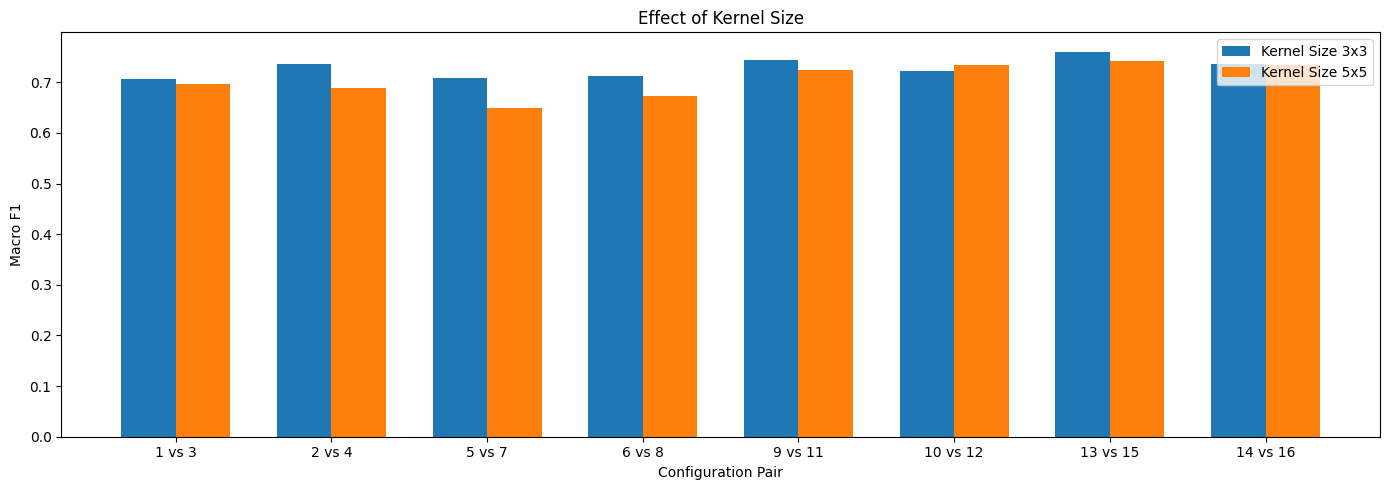

In [15]:
kernel_index_pairs = [
    (1, 3),
    (2, 4),
    (5, 7),
    (6, 8),
    (9, 11),
    (10, 12),
    (13, 15),
    (14, 16),
]

kernel_pairs = build_pairs(kernel_index_pairs)

plot_pairwise_comparison(
    pairs=kernel_pairs,
    title="Effect of Kernel Size",
    left_label="Kernel Size 3x3",
    right_label="Kernel Size 5x5",
    filename="cnn_effect_kernel_size.png"
)

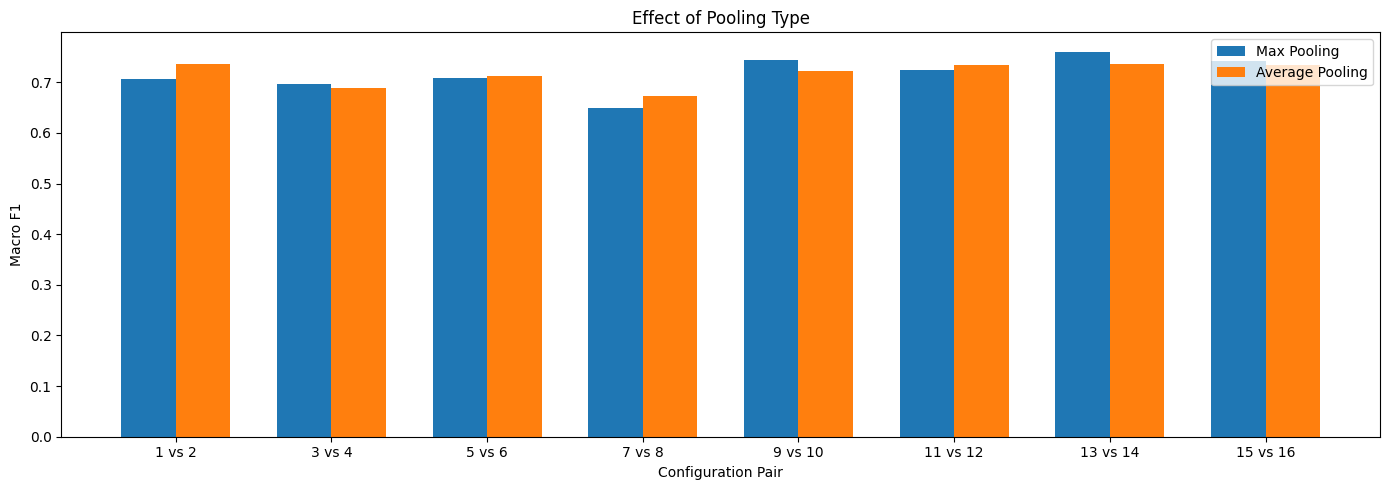

In [16]:
pooling_index_pairs = [
    (1, 2),
    (3, 4),
    (5, 6),
    (7, 8),
    (9, 10),
    (11, 12),
    (13, 14),
    (15, 16),
]

pooling_pairs = build_pairs(pooling_index_pairs)

plot_pairwise_comparison(
    pairs=pooling_pairs,
    title="Effect of Pooling Type",
    left_label="Max Pooling",
    right_label="Average Pooling",
    filename="cnn_effect_pooling.png"
)